# 📝 Tugas: Python & Data Analysis
### Studi Kasus: Data Penjualan Showroom Mobil (10 Cabang)

Kerjakan 5 soal di bawah ini. Semua soal pakai dataset yang sama seperti di kelas.

🔗 [Data Penjualan Showroom Mobil 10 Cabang](https://docs.google.com/spreadsheets/d/1GuFkH44urw4ACqt5gsWhi1Scei0pGS2L/edit?usp=drive_link&ouid=106485154383908444810&rtpof=true&sd=true)

**Petunjuk pengerjaan:**

- Isi kode kamu di cell kode yang sudah disediakan di bawah tiap soal, tepat di bawah komentar instruksi.
- Boleh nambah cell baru sendiri kalau butuh cek data dulu sebelum jawab.
- Boleh pakai fitur AI di Colab kalau stuck, tapi coba dulu sendiri ya, biar makin paham.
- Jangan lupa jalankan cell paling atas dulu (import + load data) sebelum ngerjain soal-soal di bawahnya.

**Daftar soal:**

| No | Soal | Tingkat Kesulitan |
|---|---|---|
| 1 | Ukuran & isi awal data | Gampang |
| 2 | Jumlah transaksi per kategori mobil | Gampang |
| 3 | Cabang dengan transaksi terbanyak | Gampang |
| 4 | Bersihkan dan siapkan data (cleansing + formatting) | Sedang |
| 5 | Kombinasi cabang & kategori dengan pendapatan tertinggi | Agak Sulit |

---

## Setup (jalankan dulu sebelum mulai ngerjain)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url_data = "https://docs.google.com/spreadsheets/d/1GuFkH44urw4ACqt5gsWhi1Scei0pGS2L/export?format=csv"
df = pd.read_csv(url_data)

print("Data berhasil di-load!")
print("Jumlah baris dan kolom:", df.shape)
df.head()


Data berhasil di-load!
Jumlah baris dan kolom: (10000, 16)


,sales_date,order_id,customer_name,branch,product_name,category,color,price,quantity,payment_type,trade_in,discount,total,total_sales,status,branch_address
0,2025-12-13,TRX00001,Customer_913,Jakarta,Daihatsu Xenia 1.5 R CVT,MPV,Silver Metalik,240000000,1,Cash + Trade In,74000000,0,240000000,166000000,completed,"Jl. MT. Haryono No. 12, Jakarta"
1,2025-10-15,TRX00002,Customer_261,Jakarta,Toyota Rush 1.5 S GR Sport CVT,SUV,Hitam Metalik,300000000,1,Kredit,0,0,300000000,300000000,completed,"Jl. MT. Haryono No. 12, Jakarta"
2,2025-01-04,TRX00003,Customer_4465,Kendari,Honda BR-V 1.5 E CVT,MPV,Merah,310000000,1,Kredit + Trade In,111000000,0,310000000,199000000,completed,"Jl. Ahmad Yani No. 33, Kendari"
3,2025-02-17,TRX00004,Customer_2788,Padang,Honda Brio Satya E CVT,Hatchback,Merah,190000000,1,Kredit,0,0,190000000,190000000,completed,"Jl. Khatib Sulaiman No. 10, Padang"
4,2025-10-02,TRX00005,Customer_2941,Karawang,Isuzu D-Max Double Cabin 4x4 AT,Pickup,Hitam Metalik,520000000,1,Cash + Trade In,93000000,0,520000000,427000000,refund,"Jl. Ahmad Yani No. 5, Karawang"


> ⚠️ Kalau load data-nya error, cek lagi akses sharing sheet-nya (harus "Anyone with the link" minimal Viewer), atau upload manual filenya ke Colab.


---
## Soal 1 :

Tampilkan:

1. Jumlah baris dan jumlah kolom dari data (`df`)
2. Nama-nama semua kolom yang ada
3. 10 baris pertama dari data


In [3]:
# 1. Tampilkan jumlah baris dan jumlah kolom dari df
print("jumlah_baris =", df.shape[0])
print("jumlah_kolom =", df.shape[1])
# 2. Tampilkan nama-nama semua kolom
print(df.columns)

# 3. Tampilkan 10 baris pertama dari data
df.head(10)

jumlah_baris = 10000
jumlah_kolom = 16
Index(['sales_date', 'order_id', 'customer_name', 'branch', 'product_name',
       'category', 'color', 'price', 'quantity', 'payment_type', 'trade_in',
       'discount', 'total', 'total_sales', 'status', 'branch_address'],
      dtype='object')


,sales_date,order_id,customer_name,branch,product_name,category,color,price,quantity,payment_type,trade_in,discount,total,total_sales,status,branch_address
0,2025-12-13,TRX00001,Customer_913,Jakarta,Daihatsu Xenia 1.5 R CVT,MPV,Silver Metalik,240000000,1,Cash + Trade In,74000000,0,240000000,166000000,completed,"Jl. MT. Haryono No. 12, Jakarta"
1,2025-10-15,TRX00002,Customer_261,Jakarta,Toyota Rush 1.5 S GR Sport CVT,SUV,Hitam Metalik,300000000,1,Kredit,0,0,300000000,300000000,completed,"Jl. MT. Haryono No. 12, Jakarta"
2,2025-01-04,TRX00003,Customer_4465,Kendari,Honda BR-V 1.5 E CVT,MPV,Merah,310000000,1,Kredit + Trade In,111000000,0,310000000,199000000,completed,"Jl. Ahmad Yani No. 33, Kendari"
3,2025-02-17,TRX00004,Customer_2788,Padang,Honda Brio Satya E CVT,Hatchback,Merah,190000000,1,Kredit,0,0,190000000,190000000,completed,"Jl. Khatib Sulaiman No. 10, Padang"
4,2025-10-02,TRX00005,Customer_2941,Karawang,Isuzu D-Max Double Cabin 4x4 AT,Pickup,Hitam Metalik,520000000,1,Cash + Trade In,93000000,0,520000000,427000000,refund,"Jl. Ahmad Yani No. 5, Karawang"
5,2025-07-05,TRX00006,Customer_3101,Bandung,Wuling Air ev Long Range,City Car (EV),Abu-abu,250000000,1,Kredit,0,0,250000000,250000000,completed,"Jl. Soekarno Hatta No. 88, Bandung"
6,2025-02-21,TRX00007,Customer_570,Jakarta,Honda BR-V 1.5 E CVT,MPV,Hitam Metalik,310000000,2,Kredit + Trade In,224000000,0,620000000,396000000,completed,"Jl. MT. Haryono No. 12, Jakarta"
7,2025-12-16,TRX00008,Customer_2989,Pontianak,Mitsubishi Pajero Sport Dakar 4x2 AT,SUV,Putih Pearl,580000000,1,Kredit,0,0,580000000,580000000,completed,"Jl. Ahmad Yani No. 45, Pontianak"
8,2025-11-24,TRX00009,Customer_1402,Semarang,Honda BR-V 1.5 E CVT,MPV,Silver Metalik,310000000,1,Kredit,0,0,310000000,310000000,completed,"Jl. Setiabudi No. 60, Semarang"
9,2025-07-25,TRX00010,Customer_1800,Karawang,Toyota Innova Zenix 2.0 V CVT,MPV,Hitam Metalik,450000000,1,Kredit + Trade In,167000000,0,450000000,283000000,completed,"Jl. Ahmad Yani No. 5, Karawang"


---
## Soal 2: Jumlah Transaksi per Kategori Mobil

Hitung ada berapa banyak transaksi untuk masing-masing kategori mobil (kolom `category`), diurutkan dari yang paling banyak.

**Bonus (opsional):** buat bar chart dari hasilnya.


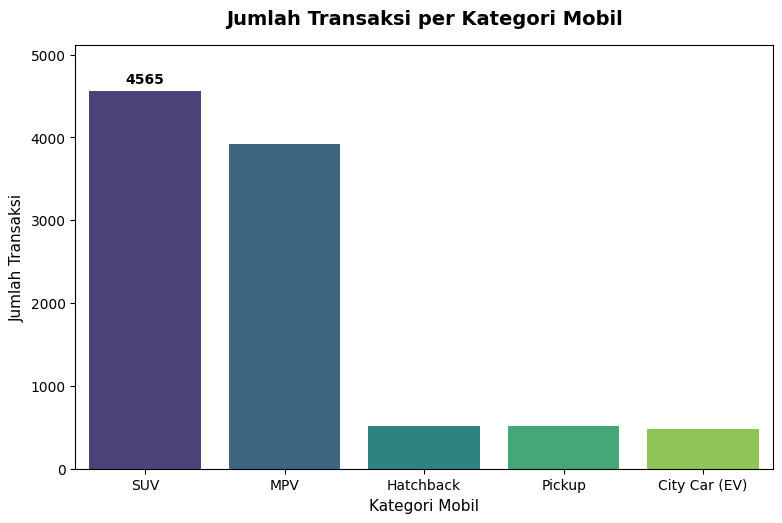

In [4]:
# Hitung jumlah transaksi per kategori mobil (category), urutkan dari yang paling banyak
df.groupby('category').size().reset_index(name='jumlah_transaksi').sort_values(by='jumlah_transaksi', ascending=False)

# (opsional) buat bar chart dari hasilnya
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hitung jumlah transaksi per kategori (data asli/presisi)
kategori_counts = df['category'].value_counts()

# 2. Buat Ukuran Canvas Chart
plt.figure(figsize=(9, 5.5))

# 3. Plot Bar Chart
ax = sns.barplot(
    x=kategori_counts.index,
    y=kategori_counts.values,
    hue=kategori_counts.index,
    palette='viridis',
    legend=False
)

# 4. Tampilkan label angka presisi di atas setiap bar
ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=10, fontweight='bold')

# 5. Atur Judul dan Label Sumbu
plt.title('Jumlah Transaksi per Kategori Mobil', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Mobil', fontsize=11)
plt.ylabel('Jumlah Transaksi', fontsize=11)

# Memberikan ruang tambahan di atas bar tertinggi agar angka tidak terpotong
plt.ylim(0, kategori_counts.max() * 1.12)

# Tampilkan chart
plt.show()

---
## Soal 3: Cabang dengan Transaksi Terbanyak

Dari semua cabang yang ada, cabang mana yang punya **jumlah transaksi terbanyak** (bukan pendapatan, tapi jumlah baris transaksinya)? Tampilkan juga angkanya.


Cabang dengan transaksi terbanyak: Jakarta (1058 transaksi)

=== REKAP SELURUH CABANG ===
branch
Jakarta      1058
Padang       1044
Malang       1044
Bandung       989
Batam         986
Pontianak     982
Palembang     981
Kendari       976
Karawang      973
Semarang      967
Name: count, dtype: int64


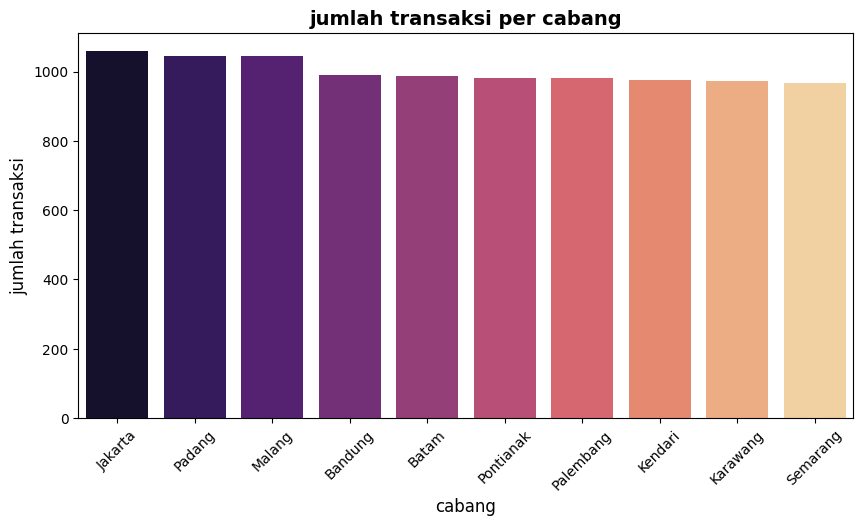

In [5]:
# Hitung jumlah transaksi per cabang (branch), urutkan dari yang paling banyak
# lalu tampilkan cabang dengan jumlah transaksi terbanyak
import matplotlib.pyplot as plt
import seaborn as sns

branch_counts = df['branch'].value_counts()

top_branch = branch_counts.index[0]
top_count = branch_counts.iloc[0]

print(f"Cabang dengan transaksi terbanyak: {top_branch} ({top_count} transaksi)\n")

print("=== REKAP SELURUH CABANG ===")
print(branch_counts)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=branch_counts.index,
    y=branch_counts.values,
    hue=branch_counts.index,
    palette='magma',
    legend=False
)

plt.title('jumlah transaksi per cabang', fontsize=14, fontweight='bold')
plt.xlabel('cabang', fontsize=12)
plt.ylabel('jumlah transaksi', fontsize=12)
plt.xticks(rotation=45)

plt.show()

---
## Soal 4: Bersihkan dan Siapkan Data

Sebelum data ini dipakai buat analisis lebih lanjut, kamu diminta membersihkan dan merapikannya dulu. Lakukan langkah-langkah berikut secara berurutan, dan simpan hasilnya ke `df` (menimpa data yang lama):

1. Cek apakah ada **missing value** di tiap kolom. Kalau kolom `trade_in` ada yang kosong, isi dengan `0`.
2. Cek apakah ada **baris duplikat** (baik duplikat penuh maupun duplikat `order_id`). Kalau ada, hapus baris duplikatnya.
3. Standarisasi kolom `payment_type`: hilangkan spasi berlebih di depan/belakang, dan samakan kapitalisasinya jadi Title Case (contoh: `"kredit"` jadi `"Kredit"`).
4. Ubah kolom `sales_date` yang masih berupa teks jadi tipe data tanggal (`datetime`).
5. Setelah semua langkah di atas selesai, tampilkan `df.info()` buat membuktikan datanya sudah lebih rapi (nggak ada missing value yang bermasalah, tipe data `sales_date` sudah benar).


In [6]:
# 1. Cek missing value, lalu isi trade_in yang kosong dengan 0
print("=== MISSING VALUES ====")
print(df.isnull().sum())

df['trade_in'] = df['trade_in'].fillna(0)

# 2. Cek dan hapus baris duplikat (baik duplikat penuh maupun duplikat order_id)
df = df.drop_duplicates(subset=['order_id'], keep='first')

# 3. Standarisasi kolom payment_type (strip + title case)
df['payment_type'] = df['payment_type'].astype(str).str.strip().str.title()

# 4. Ubah kolom sales_date jadi tipe data datetime
df['sales_date'] = pd.to_datetime(df['sales_date'])

# 5. Tampilkan df.info() untuk membuktikan data sudah lebih rapi
df.info()

=== MISSING VALUES ====
sales_date        0
order_id          0
customer_name     0
branch            0
product_name      0
category          0
color             0
price             0
quantity          0
payment_type      0
trade_in          0
discount          0
total             0
total_sales       0
status            0
branch_address    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   sales_date      10000 non-null  datetime64[ns]
 1   order_id        10000 non-null  object        
 2   customer_name   10000 non-null  object        
 3   branch          10000 non-null  object        
 4   product_name    10000 non-null  object        
 5   category        10000 non-null  object        
 6   color           10000 non-null  object        
 7   price           10000 non-null  int64         
 8   quantity  

---
## Soal 5: Kombinasi Cabang & Kategori dengan Pendapatan Tertinggi

Manajemen mau tahu: **kombinasi cabang dan kategori mobil apa** yang menghasilkan pendapatan (`total_sales`) paling besar? Ini penting buat mereka menentukan cabang mana yang perlu ditambah stok kategori tertentu.

Kerjakan langkah-langkah berikut:

1. Ambil hanya transaksi dengan status `"completed"` (transaksi yang batal/refund tidak dihitung sebagai pendapatan).
2. Kelompokkan data berdasarkan **kombinasi** `branch` dan `category` sekaligus (bukan salah satu aja), lalu jumlahkan `total_sales`-nya.
   - *Petunjuk: `groupby()` bisa menerima lebih dari satu kolom sekaligus, dengan cara `df.groupby(["kolom1", "kolom2"])`.*
3. Urutkan hasilnya dari pendapatan terbesar, lalu tampilkan **5 kombinasi cabang + kategori** dengan pendapatan tertinggi.
4. Buat bar chart horizontal dari 5 kombinasi teratas tersebut, biar gampang dipresentasikan.

**Tantangan tambahan (opsional, buat yang mau nyoba lebih jauh):** dari 5 kombinasi teratas itu, hitung juga berapa **rata-rata harga per unit** (`price`) untuk masing-masing kombinasi tersebut.


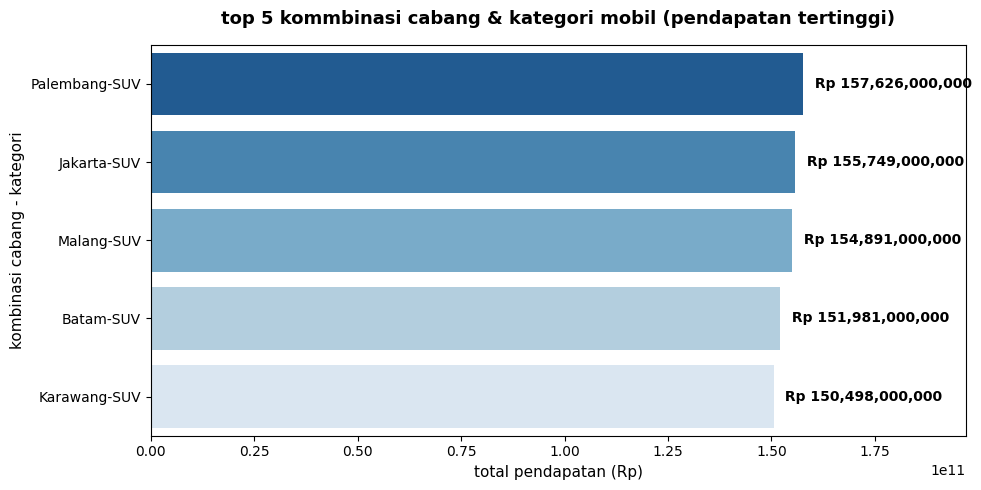


=== RATA-RATA HARGA PER UNIT (TOP 5 KOMBINASI) ===
   branch category   total_pendapatan rata_rata_harga
Palembang      SUV Rp 157,626,000,000  Rp 410,047,733
  Jakarta      SUV Rp 155,749,000,000  Rp 408,156,682
   Malang      SUV Rp 154,891,000,000  Rp 419,044,118
    Batam      SUV Rp 151,981,000,000  Rp 414,474,328
 Karawang      SUV Rp 150,498,000,000  Rp 401,286,408


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Filter transaksi yang statusnya "completed"
df_completed = df[df['status'] == 'completed']
# 2. Groupby kombinasi branch dan category, jumlahkan total_sales
# 3. Urutkan dari terbesar, ambil 5 kombinasi teratas
top5_kombinasi = (
    df_completed
    .groupby(['branch', 'category'])['total_sales']
    .sum()
    .reset_index()
    .sort_values(by='total_sales', ascending=False)
    .head(5)
)
top5_kombinasi['branch_category'] = top5_kombinasi['branch'] + "-" + top5_kombinasi['category']
# 4. Buat bar chart horizontal dari 5 kombinasi teratas
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top5_kombinasi,
    x='total_sales',
    y='branch_category',
    hue='branch_category',
    palette='Blues_r',
    legend=False
)
for p in ax.patches:
  val = p.get_width()
  ax.annotate(
      f" Rp {val:,.0f}",
      (val, p.get_y() + p.get_height() / 2.),
      ha='left',
      va='center',
      fontsize=10,
      fontweight='bold',
      xytext=(5, 0),
      textcoords='offset points'
  )
plt.title('top 5 kommbinasi cabang & kategori mobil (pendapatan tertinggi)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('total pendapatan (Rp)', fontsize=11)
plt.ylabel('kombinasi cabang - kategori', fontsize=11)
plt.xlim(0, top5_kombinasi['total_sales'].max() * 1.25)

plt.tight_layout()
plt.show()

# (opsional) Tantangan tambahan: rata-rata harga per unit untuk 5 kombinasi teratas
top5_avg_price = (
    df_completed
    .groupby(['branch', 'category'])
    .agg(
        total_pendapatan=('total_sales', 'sum'),
        rata_rata_harga=('price', 'mean')
    )
    .reset_index()
    .sort_values(by='total_pendapatan', ascending=False)
    .head(5)
)

top5_avg_price['total_pendapatan'] = top5_avg_price['total_pendapatan'].apply(lambda x: f"Rp {x:,.0f}")
top5_avg_price["rata_rata_harga"] = top5_avg_price['rata_rata_harga'].apply(lambda x: f'Rp {x:,.0f}')

print("\n=== RATA-RATA HARGA PER UNIT (TOP 5 KOMBINASI) ===")
print(top5_avg_price[['branch', 'category', 'total_pendapatan', 'rata_rata_harga']].to_string(index=False))

---
## Selesai!

Kalau udah kelar, coba cek ulang jawaban kamu satu-satu, pastikan hasilnya masuk akal (misalnya nggak ada pendapatan yang negatif atau angka yang aneh). Selamat mengerjakan! 🚗📊
